In [1]:
import numpy as np 
import matplotlib.pyplot as plt

from tensorflow import keras
from keras.datasets import mnist

# libraries for building the neural network
from keras.models import Sequential # this is for creating a linear stack of layers, what we need for a feedforward neural network
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout #dropout is for regularization to prevent overfitting


## Getting data 

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

**Plotting data**

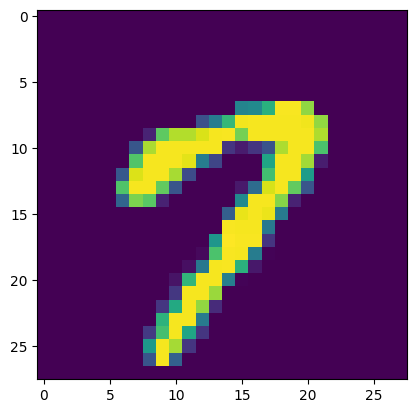

In [3]:
plt.imshow(X_train[15])

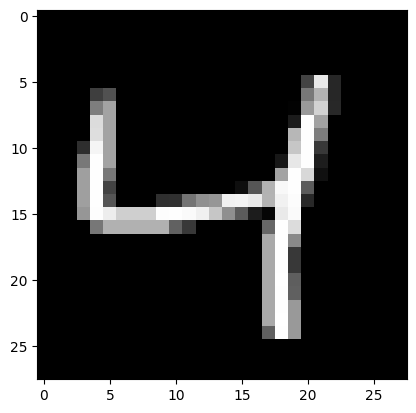

Text(0.5, 1.0, '4')

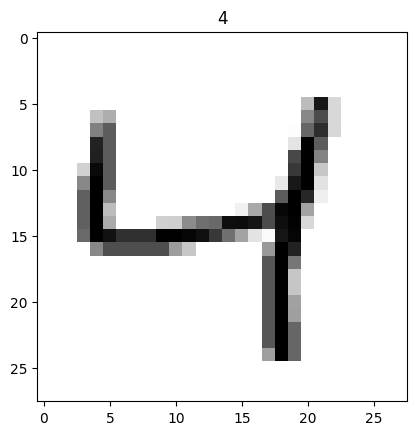

In [4]:
plt.imshow(X_train[2], cmap = 'gray')
plt.show() # allows to print the first image before it is overwritten. without it only the last image will be shown (in this case it's the binary image with its label as title)
plt.imshow(X_train[2], cmap = 'binary')
plt.title(y_train[2]) #affects the previous image

In [5]:
def plot_input(i):
    plt.imshow(X_train[i], cmap = 'binary')
    plt.title(y_train[i]) #the title is the value/digit represented by the image
    plt.show() # Tells Matplotlib: “Render the figure now” 

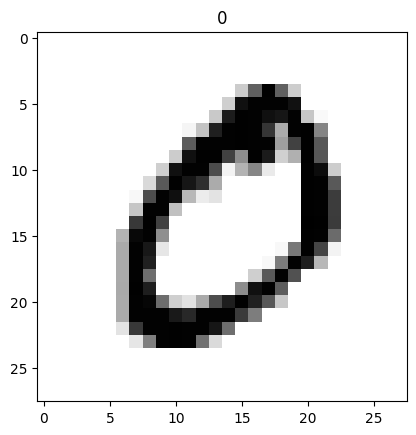

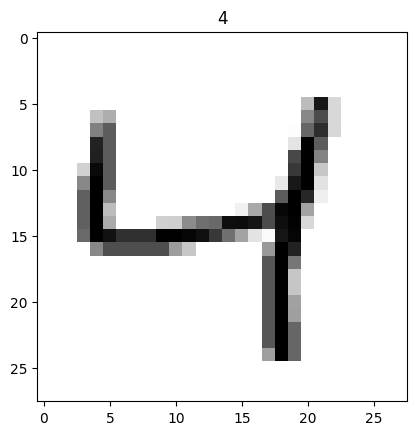

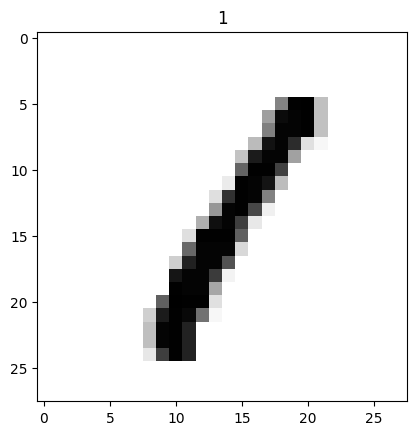

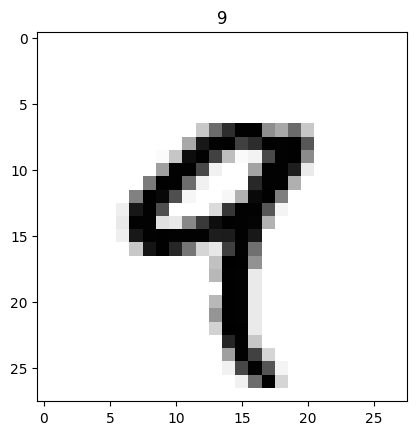

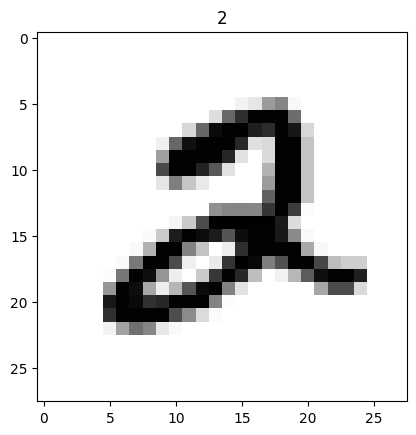

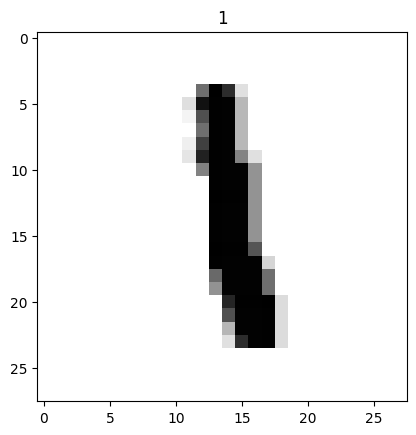

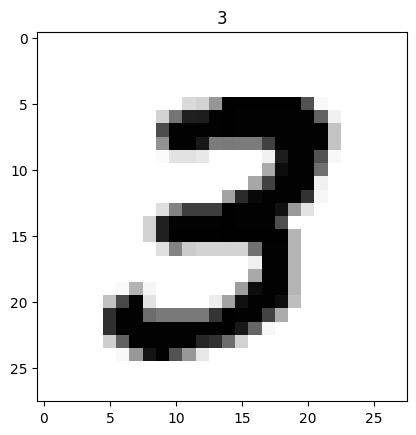

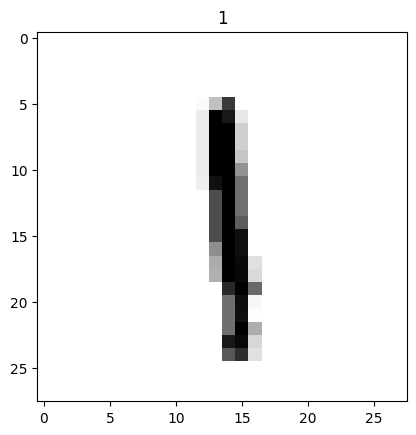

In [6]:
for i in range(1, 9):
    plot_input(i)

## Pre-process data

Normalising the data(image pixel values) from 0 – 255  to  0.0 – 1.0. I means means rescaling numerical values so they fall into a small, consistent range. 
This is important for smooother gradient at every small update, stable training, and faster convergence of the model. Pixel values are between 0 and 255, so we divide by 255.0.
Normalisation puts all data/features on equal footing so numerical bais (such as a focus on larger data) does not happen. large data could lead to vanishing gradient (~ 0), therefore no learning. 

In [7]:
# Normalize the data 
X_train = X_train.astype(np.float32) / 255 
X_test = X_test.astype(np.float32) / 255

#reshape the data to (28, 28, 1) - adding a new dimension for the channel data (note: channel data is 1 for grayscale images and 3 for RGB images)
X_train = np.expand_dims(X_train, -1) 
X_test = np.expand_dims(X_test, -1)  

# convert classes (the output variable 'y') to one-hot encoded vectors
y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test) 

In [8]:
#checking new shapes
X_train.shape, X_test.shape 
print("new x_train shape:", X_train.shape)
print("new x_test shape:", X_test.shape)

new x_train shape: (60000, 28, 28, 1)
new x_test shape: (10000, 28, 28, 1)


In [9]:
display(y_test) 
y_train 

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 10))

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(60000, 10))

In [10]:
model = Sequential() # initializes a sequential model (simplest kind of neural network model in Keras)
                    
model.add(Conv2D(32, (3, 3), input_shape = (28, 28, 1), activation = 'relu'))
model.add(MaxPool2D(pool_size = (2, 2))) # downsampling the feature maps to reduce spatial dimensions and computational load, not input depth (it is a shape reduction technique)

model.add(Conv2D(64, kernel_size = (3, 3), activation = 'relu')) #64 filters this time, to learn more complex features (parts of digits corners and curves), it is more expressive
model.add(MaxPool2D(pool_size = (2, 2))) # it splits/compresses the input into 2x2 blocks and takes the maximum value from each block, reducing the spatial dimensions by a factor of 2.

model.add(Flatten()) # flattening the 3D feature maps into 1D feature vectors, to prepare for fully connected layers (Dense layers). (5, 5, 64) → (1600,)

model.add(Dropout(0.25)) # Dropout layer for regularization, randomly sets 25% of input units to 0 during training to prevent overfitting. 
                         # 0.5 = 50% , would be slower, more robust, but can hurt performance on smaller datasets.

model.add(Dense(10, activation = 'softmax'))


C:\Users\uk000115\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary() # provides a summary of the model architecture, including the number of layers, output shapes, and number of parameters at each layer. 
                # parameter count for conv layer is calculated as: (filter_height * filter_width * number_of_filters ) + number_of_filters
                # for the next conv layer parmam # = (filter_height * filter_width * previous_layer_filters * number_of_filters ) + number_of_filters
                # maxpooling and flattern layers have no parameters to learn (no weights so no learning therefore just take the max values)
                # dense layer params = (input_units * output_units) + output_units = 64 * 10 + 10 = 650

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:

model.compile(optimizer = 'adam', loss = "categorical_crossentropy", metrics = ['accuracy']) 

In [13]:
# callbacks

from keras.callbacks import EarlyStopping, ModelCheckpoint

# earlyStopping 
es = EarlyStopping(monitor = 'val_accuracy', min_delta = 0.01, patience = 4, verbose = 1) 
# Model Checkpoint
mc = ModelCheckpoint('./best_model.keras', monitor = 'val_accuracy', verbose = 1, save_best_only = True) # could also save as .h5 or .hdf5 instead of .keras

cb = [es, mc]

## Model Training 

In [14]:
his = model.fit(X_train, y_train, epochs = 50, validation_split = 0.3, callbacks = cb) # his means history?

Epoch 1/50
1310/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8530 - loss: 0.4820
Epoch 1: val_accuracy improved from None to 0.97483, saving model to ./best_model.keras
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9326 - loss: 0.2228 - val_accuracy: 0.9748 - val_loss: 0.0837
Epoch 2/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9758 - loss: 0.0774
Epoch 2: val_accuracy improved from 0.97483 to 0.98211, saving model to ./best_model.keras
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9766 - loss: 0.0745 - val_accuracy: 0.9821 - val_loss: 0.0583
Epoch 3/50
1309/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9826 - loss: 0.0537
Epoch 3: val_accuracy improved from 0.98211 to 0.98322, saving model to ./best_model.keras
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9820 - loss: 0.0550 - val_accuracy: 0.9832 - val_loss: 0.0533
Epoch 4/50
1312/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9856 - loss: 0.0461
Epoch 4: val_acc

## Load model 

In [15]:

model_S = keras.models.load_model("C://Users//uk000115//OneDrive - IDIADA Group//Documents//Boris//Python//AI&ML//handwritten digit recognision//cnn attempt 1//best_model.keras")

## Evaluate model

In [16]:
score = model_S.evaluate(X_test, y_test)
print('Test/model accuracy:', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9914 - loss: 0.0282
Test/model accuracy: 0.9914000034332275
